In [1]:
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os,sys
from tqdm.auto import tqdm
import proplot as plot
import json,pickle
import dask.array as da
import gc
from tools import derive_var,read_and_proc,preproc_noensemble
from tools.mlr import mlr
from tools.preprocess import do_eof,preproc_maria,preproc_haiyan
from tqdm.auto import tqdm
sys.path.insert(1, '../')
import read_stuff as read
import torch
from torch.utils.data import DataLoader, TensorDataset
import vae3d
from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss
import optuna
import torch.nn.functional as F
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import math
import data_process
import random
import preproc_decomp
plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',
                'tick.labelweight':'ultralight','gridminor.linestyle':'--','title.weight':'normal','linewidth':0.5})
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

/tmp/ipykernel_3426036/2301260017.py:33: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',


In [2]:
device = 'cpu'
folds = data_process.setup_folds(n_numbers=20,indepedent_test={10,17},val_size=4,seed=42)
lassoalpha=0.2
num_rad=5

Fold 1: validation members = [4, 9, 13, 14]
Fold 2: validation members = [5, 6, 7, 18]
Fold 3: validation members = [1, 11, 12, 16]
Fold 4: validation members = [2, 8, 15, 19]
Fold 5: validation members = [0, 3, 13, 14]


In [19]:
def is_pareto_efficient(costs):
    """
    Returns a boolean array indicating whether each point is Pareto efficient.
    'costs' is an (n_points, n_costs) array, where lower values are better.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Remove dominated points
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True  # keep self
    return is_efficient

In [27]:
lassoalpha=0.1
num_rad = 5
lassodict = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')

In [32]:
lassodict['model'][5][2][0].coef_

array([ 0.        , -0.        ,  0.15083353,  0.        ,  0.        ,
        0.12094082, -0.        ,  0.14630097, -0.        ,  0.22141067])

In [21]:
TYPE='valid'
metric='MAE'
lassoalpha=0.1
import pandas as pd
complexities = []
num_rads = []
num_verts = []
for num_rad in [2,3,4,5,6,7,8,9,10]:
    results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')
    tempdict = {num_rad+numv: np.asarray([d[metric] for d in results[TYPE][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]}
    num_rads = [num_rad for _ in [2,3,4,5,6,7,8,9,10]]
    num_verts = [numv for numv in [2,3,4,5,6,7,8,9,10]]
    complexities.append(pd.DataFrame({'featurenum':list(tempdict.keys()),'metric':list(tempdict.values()),'numrad':num_rads,'numvert':num_verts}))
allcomplexities = pd.concat(complexities).reset_index(drop=False)
# Apply to your data
costs = allcomplexities[['featurenum', 'metric']].values
pareto_mask = is_pareto_efficient(costs)

In [23]:
TYPE='test'
metric='MAE'
lassoalpha=0.1
import pandas as pd
complexities = []
num_rads = []
num_verts = []
for num_rad in [2,3,4,5,6,7,8,9,10]:
    results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')
    tempdict = {num_rad+numv: np.asarray([d[metric] for d in results[TYPE][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]}
    num_rads = [num_rad for _ in [2,3,4,5,6,7,8,9,10]]
    num_verts = [numv for numv in [2,3,4,5,6,7,8,9,10]]
    complexities.append(pd.DataFrame({'featurenum':list(tempdict.keys()),'metric':list(tempdict.values()),'numrad':num_rads,'numvert':num_verts}))
allcomplexities = pd.concat(complexities).reset_index(drop=False)
pareto_df = allcomplexities[pareto_mask]
pareto_valid = allcomplexities.iloc[pareto_df.index]

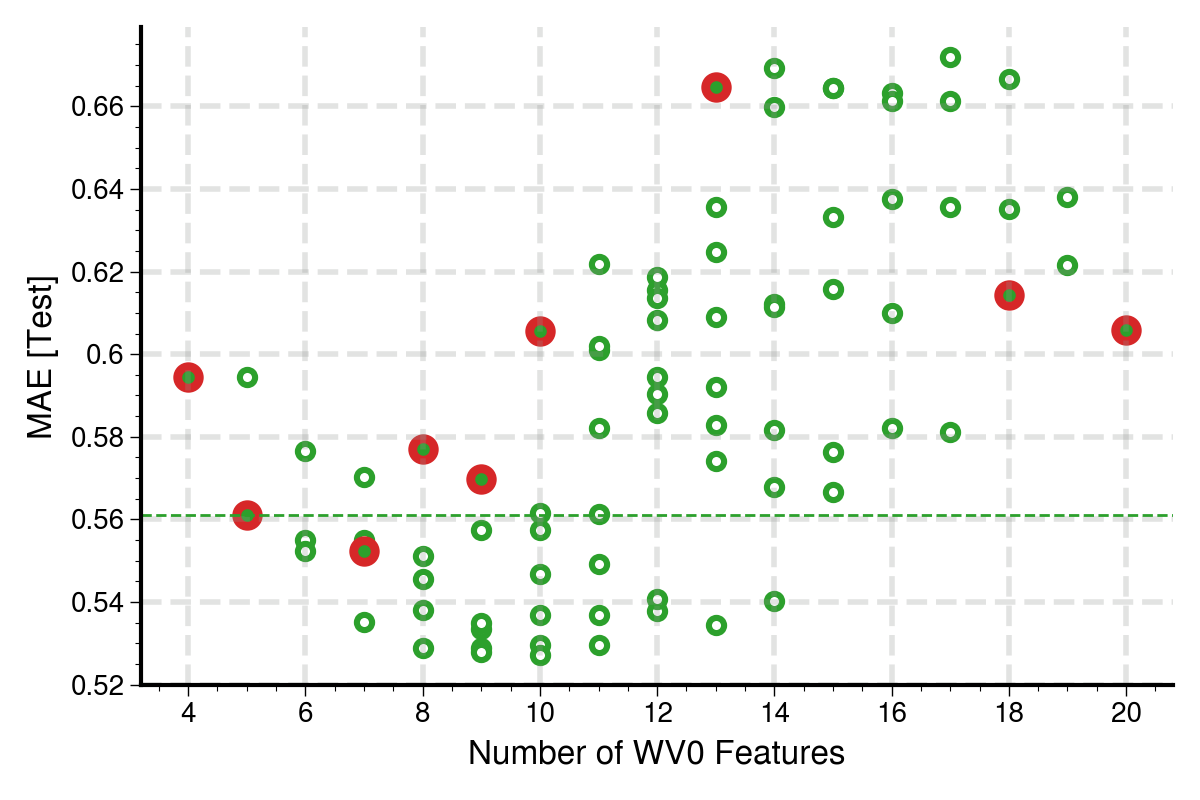

In [24]:
ig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    allcomplexities['featurenum'],
    allcomplexities['metric'],
    facecolors='white',
    edgecolors='tab:green',
    s=30,
    linewidth=2.2
)
#ax.axhline(y=0.581,lw=1,ls='--',c='tab:red',label='Valid:cVAE')
ax.axhline(y=0.561,lw=1,ls='--',c='tab:green',label='Test:cVAE')
ax.scatter(pareto_valid['featurenum'],pareto_valid['metric'],
           facecolors='tab:green',
           edgecolors='tab:red',
           s=60,
           linewidth=3.2)
# Improve axis labels and style
ax.set_xlabel('Number of WV0 Features', fontsize=12)
ax.set_ylabel('MAE [Test]', fontsize=12)
#ax.set_title('Feature Complexity vs. Metric', fontsize=14, weight='bold')

# Adjust aspect ratio and grid
ax.set_aspect('auto')  # or 'equal' if you want a 1:1 ratio
ax.grid(True, linestyle='--', linewidth=2, alpha=0.26, c='gray')

# Tweak axis and spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_linewidth(1.5)
    
ax.tick_params(axis='both', which='major', labelsize=10)

plt.tight_layout()
#plt.savefig('./valid_lasso0.2_skills_wv0_withcVAE.png',dpi=400)
plt.show()